In [2]:
import pandas as pd
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. First we need to find all the variables and their ranges
# (As it turns out, this sucks)
# -----------------------------
colspecs = [
    (1788, 1795),  # X9MTHETK5   5th grade math
    (1547, 1554),  # X9RTHETK5   5th grade reading
    (1724, 1732),  # X1MTHETK5   kindergarten math
    (1483, 1491),  # X1RTHETK5   kindergarten reading
    (1772, 1780),  # X7MTHETK5   3rd grade math
    (1531, 1539),  # X7RTHETK5   3rd grade reading
    (4468, 4475),  # X9SESL_I    socioeconomic status
    (4342, 4344),  # X9POVTY_I   poverty status
    (4008, 4010),  # X9PAR1ED_I  parent 1 education
    (4098, 4100),  # X9PAR2ED_I  parent 2 education
    (3758, 3760),  # X_CHSEX_R   sex
    (3780, 3782),  # X_RACETH_R  race/ethnicity
    (4452, 4454),  # X9DISABL    disability status
    (3790, 3792),  # X9LANGST    primary language at home
    (4521, 4523),  # X9SCTYP     school type
    (4507, 4509),  # X9PUBPRI    public vs private
]

names = [
    "math_5th",
    "reading_5th",
    "math_k",
    "reading_k",
    "math_3rd",
    "reading_3rd",
    "ses",
    "poverty",
    "parent1_edu",
    "parent2_edu",
    "sex",
    "race",
    "disability",
    "language",
    "school_type",
    "public_private",
]

# -----------------------------
# 2. Read only /1 from each 27-line record
# -----------------------------
file_path = r"C:\Users\Robert\OneDrive\Desktop\DIY Java\ds-studio-ii\DataSets\childK5p.dat"

selected_lines = []
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if i % 27 == 0:   # keep only /1
            selected_lines.append(line.rstrip("\n"))

# -----------------------------
# 3. Build dataframe
# Turns out it's NOT exactly like a .csv
# -----------------------------
df = pd.read_fwf(
    StringIO("\n".join(selected_lines)),
    colspecs=colspecs,
    names=names
)

# -----------------------------
# 4. Replace common missing codes
# Cleaning codes. All sentinel numbers can be replaced with NaN
# -----------------------------
missing_codes = [-1, -2, -3, -7, -8, -9]
df = df.replace(missing_codes, pd.NA)

# -----------------------------
# 5. Show result
# Let's see how it looks
# -----------------------------
print("Dataset preview:")
print(df.head())

print("\nColumn info:")
print(df.info())

print("\nMissing values by column:")
print(df.isna().sum())

Dataset preview:
  math_5th reading_5th  math_k reading_k math_3rd reading_3rd     ses  \
0   2.2626      2.0611 -0.2933    -0.514    1.886      1.6618 -0.5030   
1      NaN         NaN -1.0462    -1.408      NaN         NaN     NaN   
2      NaN         NaN     NaN       NaN      NaN         NaN  1.8704   
3      NaN         NaN -2.3439   -2.3133   1.4991      0.7186     NaN   
4      NaN         NaN -1.1476   -0.7437      NaN         NaN     NaN   

   poverty  parent1_edu parent2_edu sex race disability language school_type  \
0      2.0          5.0        <NA>   1    1        2.0      2.0         4.0   
1      NaN          NaN         NaN   2    1        NaN      NaN         NaN   
2      3.0          9.0        <NA>   1    3        2.0      2.0        <NA>   
3      NaN          NaN         NaN   1    1        NaN      NaN         NaN   
4      NaN          NaN         NaN   2    3        NaN      NaN         NaN   

  public_private  
0            1.0  
1            NaN  
2     

In [3]:
# 3rd grade math scores look weird (too many missing values). Dr. Bennett said to check the head and shape, let's try that
df["math_3rd"].value_counts(dropna=False).head(10)
df["math_3rd"].value_counts(dropna=False).shape

(8728,)

In [4]:
# Okay if this doesn't work we're finding a new data set
print("Total rows:", len(df))
print("math_3rd missing count:", df["math_3rd"].isna().sum())
print("math_3rd missing proportion:", df["math_3rd"].isna().mean())

Total rows: 18174
math_3rd missing count: 5308
math_3rd missing proportion: 0.2920655882029273


IT WORKS

I've spent the last ~2 hour trying to figure out why most of the values for the 3rd grade scores was mostly empty. I'm normally fine to chalk it up to data set issues if it's a little weird, but I thought >99% of the values were NaN, which would reasonably mean I parsed it wrong. Turns out when you get a top 10 of a continuous value, you're going to see a TON of representation for the "no value" value.


### So, we've down ALL THIS WORK to make sure the data set can be used. Now, I need to idenfity my stance. I plan to predict the likelihood of a child achieving a "gifted learner" status by grade 5 given a number of factors in their formative elementary years. The variables I'm testing will be a given child's:
Math and Reading scores for kindergarten and 3rd grade to track trajectory
Parent's education levels
Poverty status
The primary language spoken in the home
Gender
Race
Disability status
Socioeconomic Status (This has been removed)
Type of school attended (public vs private)
The Type of School (Catholic, Non-catholic religious, alternative private, public)

With these in mind, I'm defining a "gifted child" as a child with math or reading scores in the top 15% of students in the survey.

In [5]:
# But first, let's re-identify some of these values
print(df.columns)


Index(['math_5th', 'reading_5th', 'math_k', 'reading_k', 'math_3rd',
       'reading_3rd', 'ses', 'poverty', 'parent1_edu', 'parent2_edu', 'sex',
       'race', 'disability', 'language', 'school_type', 'public_private'],
      dtype='object')


In [6]:
# Establish the gifted learner threshold as scoring within the top 15% of students
threshold_math = df["math_k"].quantile(0.85)
threshold_read = df["reading_k"].quantile(0.85)

df["gifted_k"] = (
    (df["math_k"] >= threshold_math) | (df["reading_k"] >= threshold_read))
# Sanity Check:
df["gifted_k"].value_counts()

gifted_k
False    14848
True      3326
Name: count, dtype: int64

In [7]:
# And I intend to classify successful 5th graders on the same metric: top 15% of either categories:

# Compute thresholds
threshold_math_5 = df["math_5th"].quantile(0.85)
threshold_read_5 = df["reading_5th"].quantile(0.85)

# Create success variable
df["success_5th"] = (
    (df["math_5th"] >= threshold_math_5) |
    (df["reading_5th"] >= threshold_read_5)
)

df["success_5th"].value_counts()

success_5th
False    15617
True      2557
Name: count, dtype: int64

In [8]:
# Make sure values are read in properly
pd.crosstab(df["gifted_k"], df["success_5th"], normalize="index")

success_5th,False,True
gifted_k,,
False,0.914265,0.085735
True,0.613951,0.386049


In [9]:
# Did a lot of work where I included the value we're hoping to predict IN the model, so I'm now removing the 5th grade math/reading values

features = [
    "math_k",
    "reading_k",
    "math_3rd",
    "reading_3rd",
    "ses",
    "poverty",
    "parent1_edu",
    "parent2_edu",
    "sex",
    "race",
    "disability",
    "language",
    "school_type",
    "public_private"
]

target = "success_5th"

# Keep only the columns you actually want
df_model = df[features + [target]].dropna().copy()

In [10]:
# Sanity check
print(df_model.columns.tolist())
print(df_model.shape)

['math_k', 'reading_k', 'math_3rd', 'reading_3rd', 'ses', 'poverty', 'parent1_edu', 'parent2_edu', 'sex', 'race', 'disability', 'language', 'school_type', 'public_private', 'success_5th']
(5938, 15)


In [11]:
print("features =", features)
print("target =", target)
print("selected columns =", features + [target])

df_model = df.loc[:, features + [target]].dropna().copy()

print("\ndf_model columns =", df_model.columns.tolist())
print("shape =", df_model.shape)

features = ['math_k', 'reading_k', 'math_3rd', 'reading_3rd', 'ses', 'poverty', 'parent1_edu', 'parent2_edu', 'sex', 'race', 'disability', 'language', 'school_type', 'public_private']
target = success_5th
selected columns = ['math_k', 'reading_k', 'math_3rd', 'reading_3rd', 'ses', 'poverty', 'parent1_edu', 'parent2_edu', 'sex', 'race', 'disability', 'language', 'school_type', 'public_private', 'success_5th']

df_model columns = ['math_k', 'reading_k', 'math_3rd', 'reading_3rd', 'ses', 'poverty', 'parent1_edu', 'parent2_edu', 'sex', 'race', 'disability', 'language', 'school_type', 'public_private', 'success_5th']
shape = (5938, 15)


In [12]:
print(df["race"].unique())


[1 3 2 5 8 <NA> 7 4 6]


In [13]:
# Obligatory one-hot-encoding step
df_model = pd.get_dummies(df_model, columns=[
    "sex", "race", "language", "school_type", "public_private"
], drop_first=True)
# Re-train with the unnecessary "ses" variable dropped
df_model = df_model.drop(columns=["ses"])

# Make sure to separate the data set between features and target
X = df_model.drop(columns=["success_5th"])
y = df_model["success_5th"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

In [14]:
# See which if any columns haven't been one-hot encoded
for col in X.columns:
    try:
        pd.to_numeric(X[col])
    except Exception as e:
        print(f"{col}: {e}")

In [15]:
bad_col = "reading_3rd"

mask = pd.to_numeric(X[bad_col], errors="coerce").isna()
print(X.loc[mask, bad_col].head(20))

Series([], Name: reading_3rd, dtype: object)


In [16]:
test_specs = [
    (1531, 1539),  # candidate
]

test_names = ["reading_3rd_test"]

df_test = pd.read_fwf(
    StringIO("\n".join(selected_lines)),
    colspecs=test_specs,
    names=test_names
)

print(df_test["reading_3rd_test"].head(20))
print(pd.to_numeric(df_test["reading_3rd_test"], errors="coerce").isna().mean())

0     1.6618
1     0.7186
2     0.6492
3     0.8526
4     1.3038
5     0.5704
6     1.2335
7     1.4287
8     1.4636
9     1.3208
10    1.3514
11    1.7384
12    1.4564
13    0.9706
14    0.8618
15    0.2819
16    1.1612
17    1.0566
18    1.3130
19    0.8651
Name: reading_3rd_test, dtype: float64
0.0


In [17]:
print("X_train missing total:", X_train.isna().sum().sum())
print("X_test missing total:", X_test.isna().sum().sum())
print("y_train missing total:", y_train.isna().sum())
print("y_test missing total:", y_test.isna().sum())

print("\nColumns with missing values in X_train:")
print(X_train.columns[X_train.isna().any()])

print("\nObject dtype columns in X_train:")
print(X_train.dtypes[X_train.dtypes == "object"])

X_train missing total: 0
X_test missing total: 0
y_train missing total: 0
y_test missing total: 0

Columns with missing values in X_train:
Index([], dtype='object')

Object dtype columns in X_train:
math_k         object
reading_k      object
math_3rd       object
reading_3rd    object
parent2_edu    object
disability     object
dtype: object


In [18]:
for col in X_train.columns:
    try:
        pd.to_numeric(X_train[col])
    except Exception as e:
        print(f"{col}: {e}")

In [19]:
# Now we just pray everything is working



model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
# Okay hang on because I think this is working. Testing the first few variables to make sure...
model.predict(X_train[:4])

array([False,  True, False,  True])

In [21]:
# I won't swear in the file, because that seems uncouth, but holy smack.

# Checking the accuracy of the logistical regression model:


accuracy_score(y_test, model.predict(X_test))

0.8518518518518519

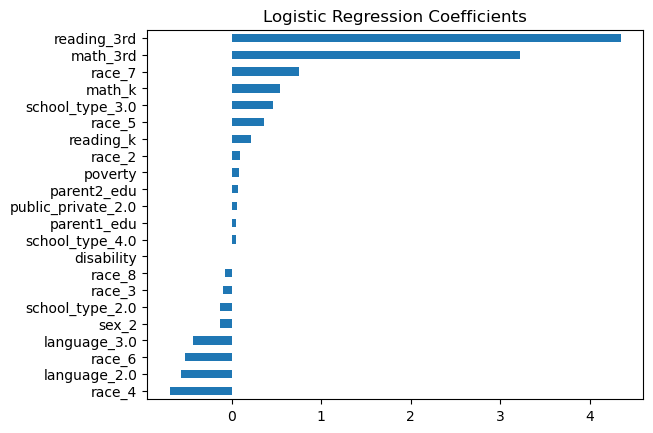

In [22]:


coef = pd.Series(model.coef_[0], index=X_train.columns)
coef.sort_values().plot(kind='barh')
plt.title("Logistic Regression Coefficients")
plt.show()

In [23]:
# Testing for possibility of skewed data based on racial group population:
df['race'].value_counts()

race
1    8488
3    4207
2    2396
5    1543
8     827
4     385
7     168
6     117
Name: count, dtype: int64

After evaluating the dataset for the population of each racial group, there is a clear representation gap between the top and bottom four groups. Maybe remove racial categories?

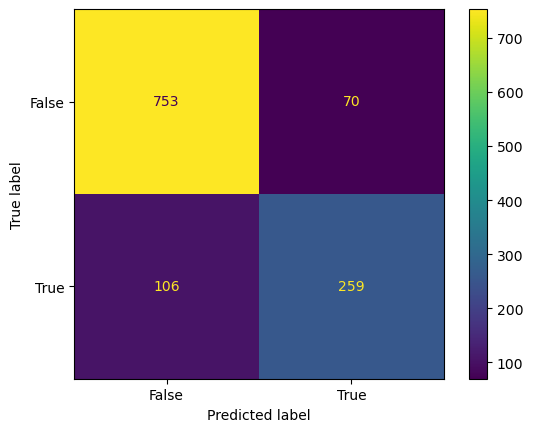

In [24]:


ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [25]:

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

       False       0.88      0.91      0.90       823
        True       0.79      0.71      0.75       365

    accuracy                           0.85      1188
   macro avg       0.83      0.81      0.82      1188
weighted avg       0.85      0.85      0.85      1188



##### 85% accuracy is solid. I'd love it higher, but I'm glad I avoided the 99% issue (this time). I suspect this will be the highest accuracy score, but I'll create a decision tree and a random forest for veracity. 

In [26]:


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_model = DecisionTreeClassifier(max_depth=6)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

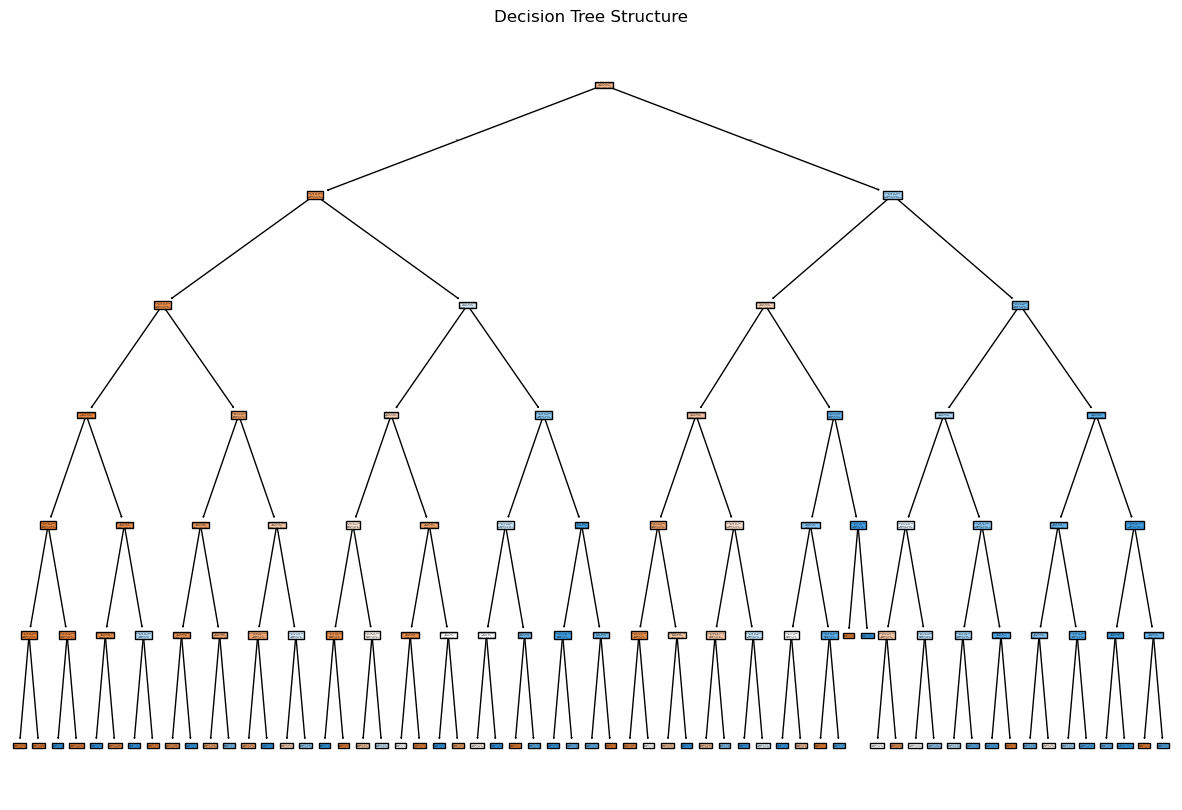

In [27]:


plt.figure(figsize=(15,10))
plot_tree(dt_model, feature_names=X_train.columns, filled=True)
plt.title("Decision Tree Structure")
plt.show()

#### After testing various tree depths, any depth after 4 produces a tree that is very difficult to read.

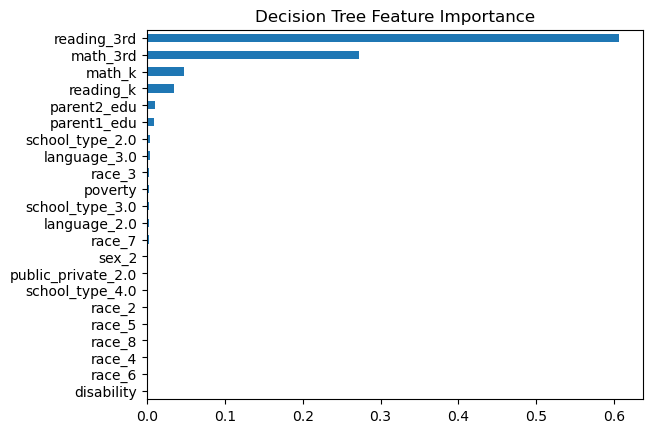

In [28]:
#### An importance matrix (which I did NOT know existed) could be a good way forward...
importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh')
plt.title("Decision Tree Feature Importance")
plt.show()

#### There are a wealth of similarities between the regression model and the decision tree model: Both models placed performance in kindergarten and 3rd grade as significant indicators. Following that, the parents level of education was the next most substantial contributor to a student performing well in 5th grade.

In [29]:


print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.8425925925925926
              precision    recall  f1-score   support

       False       0.86      0.93      0.89       823
        True       0.80      0.65      0.72       365

    accuracy                           0.84      1188
   macro avg       0.83      0.79      0.80      1188
weighted avg       0.84      0.84      0.84      1188



In [30]:


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

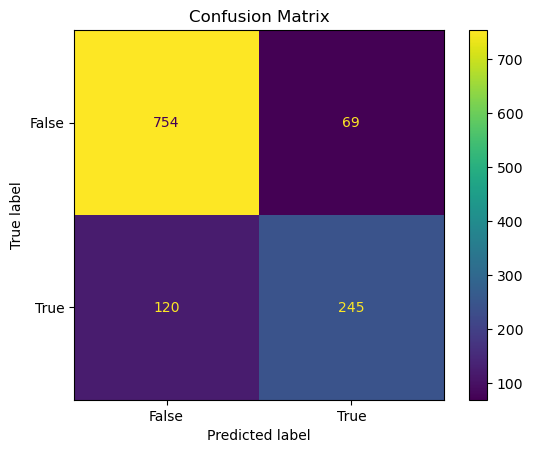

In [31]:


ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

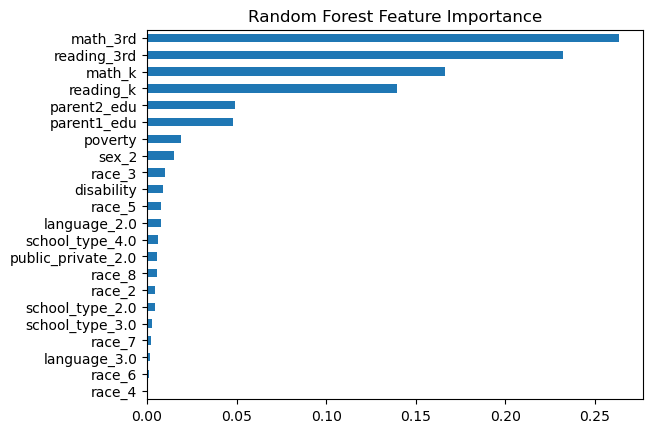

In [32]:
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
rf_importances.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

In [33]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.8409090909090909
              precision    recall  f1-score   support

       False       0.86      0.92      0.89       823
        True       0.78      0.67      0.72       365

    accuracy                           0.84      1188
   macro avg       0.82      0.79      0.81      1188
weighted avg       0.84      0.84      0.84      1188



In [34]:
print("Logistic Regression:", accuracy_score(y_test, model.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt_preds))
print("Random Forest:", accuracy_score(y_test, rf_preds))

Logistic Regression: 0.8518518518518519
Decision Tree: 0.8425925925925926
Random Forest: 0.8409090909090909


Overall, the most effective model is the logistic regression model. It's important to keep in mind the flaws present in each system:
    Bias towards predicting negative class
    Lack of even representation among all racial groups
    The model isn't reliable enough to be used as the sole deciding factor on a child's academic trajectory; best used as a tool to aid in decision making.